## Trabajo Práctico N°2: Predicción de lluvia en Australia.


## Aprendizaje Automático I

Mayo 2026

Estudiantes:

Diez Laureano

Duvia Uriel

Quispe Rocio



## Objetivos

Familiarizarse con la biblioteca scikit-learn y las herramientas que brinda para el pre-procesamiento de datos, la implementación de modelos de clasificación y la evaluación de métricas, con TensorFlow para el entrenamiento de redes neuronales y con Docker para la puesta en producción del modelo seleccionado como el más adecuado, entre otras.

## Dataset

El dataset se llama weatherAUS_2026C1.csv y contiene información climática de Australia de los últimos diez años, incluyendo si para el día siguiente llovió o no en la columna ‘RainTomorrow’. El objetivo del trabajo práctico es armar un ejecutable de Docker para predecir, a las 23:59hs de cada día, si el día siguiente va a llover o no.

Tiene una columna ‘Location’ que indica la ciudad donde se obtuvo la observación. 


##  Descripción de las variables


| Variable | Tipo | Descripción |
|----------|------|-------------|
| `Date` | Temporal | Fecha de la observación |
| `Location` | Categórica nominal | Ciudad donde se registraron los datos |
| `MinTemp` | Continua | Temperatura mínima del día (°C) |
| `MaxTemp` | Continua | Temperatura máxima del día (°C) |
| `Rainfall` | Continua | Cantidad de lluvia registrada durante el día (mm) |
| `Evaporation` | Continua | Cantidad de evaporación (mm) |
| `Sunshine` | Continua | Cantidad de horas de sol |
| `WindGustDir` | Categórica nominal | Dirección de la ráfaga máxima de viento |
| `WindGustSpeed` | Continua | Velocidad máxima del viento (km/h) |
| `WindDir9am` | Categórica nominal | Dirección del viento a las 9 AM |
| `WindDir3pm` | Categórica nominal | Dirección del viento a las 3 PM |
| `WindSpeed9am` | Continua | Velocidad del viento a las 9 AM (km/h) |
| `WindSpeed3pm` | Continua | Velocidad del viento a las 3 PM (km/h) |
| `Humidity9am` | Continua | Humedad relativa a las 9 AM (%) |
| `Humidity3pm` | Continua | Humedad relativa a las 3 PM (%) |
| `Pressure9am` | Continua | Presión atmosférica a las 9 AM (hPa) |
| `Pressure3pm` | Continua | Presión atmosférica a las 3 PM (hPa) |
| `Cloud9am` | Continua | Cobertura de nubes a las 9 AM (0 = despejado, 8 = cubierto) |
| `Cloud3pm` | Continua | Cobertura de nubes a las 3 PM (0 = despejado, 8 = cubierto) |
| `Temp9am` | Continua | Temperatura a las 9 AM (°C) |
| `Temp3pm` | Continua | Temperatura a las 3 PM (°C) |
| `RainToday` | Categórica binaria | Indica si llovió en el día actual (Yes/No) |
| `RainTomorrow` | Categórica binaria | Indica si lloverá al día siguiente (Yes/No) (**variable objetivo**) |
| `RainfallTomorrow` | Continua | Cantidad de lluvia del día siguiente (mm) |

# 1. Configuración del entorno y carga de datos  

Configuración del entorno



In [43]:
# Se importan las librerías necesarias
import pandas as pd
import numpy as np
import math

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import OneHotEncoder

In [44]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

Carga de datos

In [45]:
df = pd.read_csv('weatherAUS_2026C1.csv')

# 2. Inspección estructural del dataset  

In [46]:
print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
print()

Dimensiones del dataset: 145412 filas x 25 columnas
Memoria utilizada: 74.53 MB



Visualización general del dataset

In [47]:
df.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


Se observa una columna que es irrelevante para el trabajo.

Visualización de los datos

In [48]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

Se observan muchas variables con datos nulos.

Limpieza inicial de datos

La variable "RainTomorrow" será excluida de esta clasificación ya que corresponde a la variable objetivo del problema de clasificación.

Esta variable será utilizada como etiqueta (target) durante el entrenamiento del modelo, por lo que no debe incluirse dentro del conjunto de variables predictoras.

In [ ]:
# Eliminamos columna (índice viejo) y RainTomorrow
df = df.drop(columns=["Unnamed: 0", "RainTomorrow"], errors="ignore")


In [57]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 22 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145412 non-null  datetime64[us]
 1   Location       145412 non-null  str           
 2   MinTemp        143928 non-null  float64       
 3   MaxTemp        144159 non-null  float64       
 4   Rainfall       142152 non-null  float64       
 5   Evaporation    82658 non-null   float64       
 6   Sunshine       75616 non-null   float64       
 7   WindGustDir    135096 non-null  str           
 8   WindGustSpeed  135159 non-null  float64       
 9   WindDir9am     134850 non-null  str           
 10  WindDir3pm     141186 non-null  str           
 11  WindSpeed9am   143645 non-null  float64       
 12  WindSpeed3pm   142351 non-null  float64       
 13  Humidity9am    142759 non-null  float64       
 14  Humidity3pm    140907 non-null  float64       
 15  Pressure9am

In [58]:
# Convertimos la fecha en formato datetime
df["Date"] = pd.to_datetime(df["Date"])

Visualización de datos nulos

In [59]:
df.isnull().sum()

Date                 0
Location             0
MinTemp           1484
MaxTemp           1253
Rainfall          3260
Evaporation      62754
Sunshine         69796
WindGustDir      10316
WindGustSpeed    10253
WindDir9am       10562
WindDir3pm        4226
WindSpeed9am      1767
WindSpeed3pm      3061
Humidity9am       2653
Humidity3pm       4505
Pressure9am      15061
Pressure3pm      15024
Cloud9am         55870
Cloud3pm         59336
Temp9am           1766
Temp3pm           3607
RainToday         3260
dtype: int64

In [ ]:
# Porcentaje de datos nulos
porc_nulos = df.isnull().sum()/len(df)*100
col_nulos = porc_nulos[porc_nulos>0].sort_values(ascending=False)

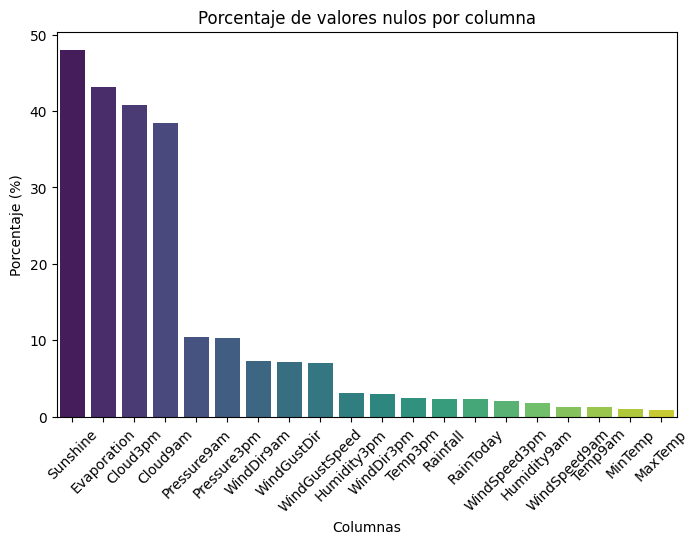

In [61]:
plt.figure(figsize=(8,5))
sns.barplot(x=col_nulos.index, y=col_nulos.values, palette='viridis')

plt.title('Porcentaje de valores nulos por columna')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Columnas')
plt.xticks(rotation=45)
plt.show()

### Separación de variables

Se separarán las variables del dataset en variables numéricas y categóricas según su tipo de dato.


In [62]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()


print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Variables categoricas (5): ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


In [63]:
# Estadísticas descriptivas
df.describe()

,Date,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,145412,143928.000000,144159.000000,142152.000000,82658.000000,75616.000000,135159.000000,143645.000000,142351.000000,142759.000000,140907.000000,130351.000000,130388.000000,89542.000000,86076.000000,143646.000000,141805.000000
mean,2013-04-04 08:55:50.149919,12.196528,23.223064,2.361516,5.468616,7.611241,40.036668,14.067277,18.661899,68.861521,51.532206,1017.647237,1015.255080,4.447287,4.509770,16.991981,21.683360
min,2007-11-01 00:00:00,-9.700000,-5.100000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.300000,977.400000,0.000000,0.000000,-8.000000,-5.800000
25%,2011-01-10 00:00:00,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,12.000000,57.000000,36.600000,1012.900000,1010.400000,1.000000,2.000000,12.300000,16.600000
50%,2013-06-02 00:00:00,12.000000,22.600000,0.000000,4.800000,8.400000,38.000000,13.000000,18.000000,69.900000,52.000000,1017.600000,1015.200000,5.000000,5.000000,16.700000,21.100000
75%,2015-06-14 00:00:00,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.100000,65.700000,1022.400000,1020.000000,7.000000,7.000000,21.600000,26.400000
max,2017-06-24 00:00:00,34.100000,49.100000,371.000000,145.000000,14.500000,135.000000,130.000000,86.000000,100.000000,100.000000,1041.200000,1039.800000,9.000000,9.000000,39.800000,47.000000
std,NaN,6.417956,7.135927,8.479338,4.193871,3.785612,13.648259,8.936768,8.865457,19.062866,20.844414,7.113833,7.044507,2.887161,2.720306,6.509191,6.953072


# 3. Análisis descriptivo de variables 

In [69]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 115)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
MinTemp,12.196528,12.0,6.417956,52.621169,-9.7,7.6,12.0,16.9,34.1,0.019449,-0.478637
MaxTemp,23.223064,22.6,7.135927,30.727759,-5.1,17.9,22.6,28.2,49.1,0.218606,-0.221082
Rainfall,2.361516,0.0,8.479338,359.063354,0.0,0.0,0.0,0.8,371.0,9.834819,178.099955
Evaporation,5.468616,4.8,4.193871,76.689792,0.0,2.6,4.8,7.4,145.0,3.761159,45.041191
Sunshine,7.611241,8.4,3.785612,49.737121,0.0,4.8,8.4,10.6,14.5,-0.496503,-0.829508
WindGustSpeed,40.036668,38.0,13.648259,34.089399,6.0,31.0,38.0,48.0,135.0,0.867216,1.402022
WindSpeed9am,14.067277,13.0,8.936768,63.528769,0.0,7.0,13.0,19.0,130.0,0.787317,1.219027
WindSpeed3pm,18.661899,18.0,8.865457,47.505651,0.0,12.0,18.0,24.0,86.0,0.616980,0.730063
Humidity9am,68.861521,69.9,19.062866,27.682901,0.0,57.0,69.9,83.1,100.0,-0.486012,-0.042284
Humidity3pm,51.532206,52.0,20.844414,40.449296,0.0,36.6,52.0,65.7,100.0,0.031449,-0.509916


In [72]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 105)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
   MinTemp: sesgo=+0.019 [aproximadamente simetrica], curtosis=-0.479 [mesocurtica]
   MaxTemp: sesgo=+0.219 [aproximadamente simetrica], curtosis=-0.221 [mesocurtica]
  Rainfall: sesgo=+9.835 [sesgo positivo (alto)], curtosis=+178.100 [leptocurtica (colas pesadas)]
  Evaporation: sesgo=+3.761 [sesgo positivo (alto)], curtosis=+45.041 [leptocurtica (colas pesadas)]
  Sunshine: sesgo=-0.497 [aproximadamente simetrica], curtosis=-0.830 [platicurtica (colas livianas)]
  WindGustSpeed: sesgo=+0.867 [sesgo positivo (moderado)], curtosis=+1.402 [leptocurtica (colas pesadas)]
  WindSpeed9am: sesgo=+0.787 [sesgo positivo (moderado)], curtosis=+1.219 [leptocurtica (colas pesadas)]
  WindSpeed3pm: sesgo=+0.617 [sesgo positivo (moderado)], curtosis=+0.730 [leptocurtica (colas pesadas)]
  Humidity9am: sesgo=-0.486 [aproximadamente simetrica], curtosis=-0.042 [mesocurtica]
  Humidity3pm: sesgo=+0.031 [aproximadamente simetrica], curtosis=-0.510 [platicurtica (co

### Distribuciones de Variables numéricas

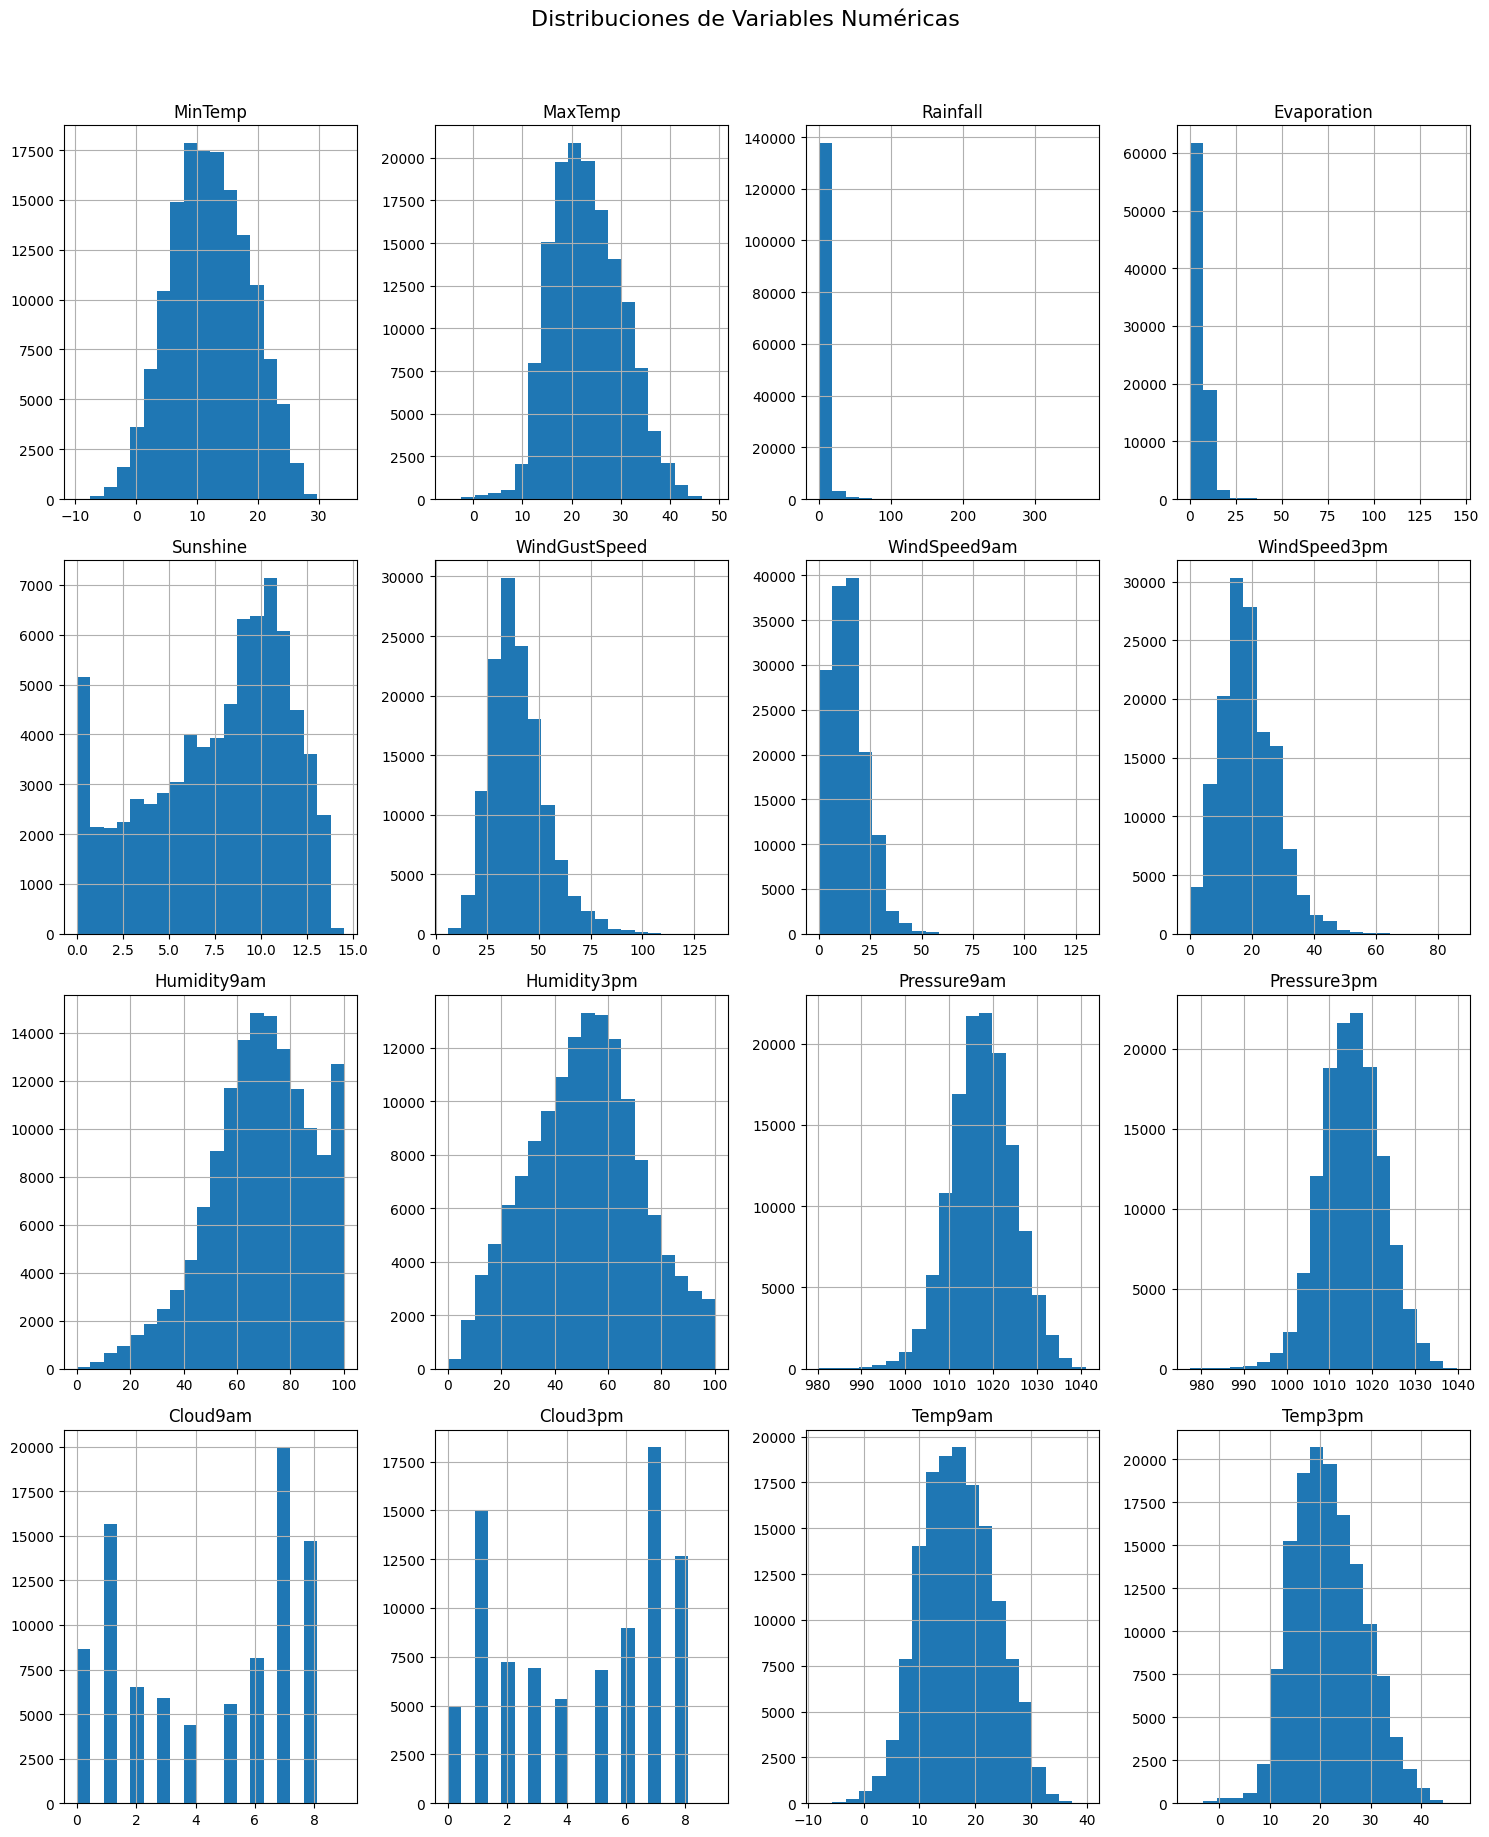

In [76]:
df[cols_numericas].hist(figsize=(15, 22), bins=20, layout=(5, 4))
plt.suptitle('Distribuciones de Variables Numéricas', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

Interpretación

Temperaturas

Las variables de temperatura ("MinTemp", "MaxTemp", "Temp9am", "Temp3pm") presentan medias y medianas muy similares, lo que indica distribuciones aproximadamente simétricas.

El sesgo cercano a cero confirma esta simetría, mientras que la curtosis ligeramente negativa indica distribuciones sin colas extremas.

Además, el coeficiente de variación es moderado (30%–50%), lo que refleja una variabilidad esperable en este tipo de mediciones.

Se trata de variables estables y bien comportadas.


Rainfall

La variable "Rainfall" presenta una gran diferencia entre la media (2.36) y la mediana (0), lo que indica una fuerte asimetría.

El coeficiente de variación es extremadamente alto (359%), y el sesgo (9.83) junto con la curtosis (178) confirman una distribución altamente sesgada con valores extremos.

Esto refleja que la mayoría de los días no llueve, pero cuando ocurre esto, puede haber precipitaciones muy intensas.

Se trata de una variable con alta variabilidad y presencia de outliers.


Evaporation y Sunshine

Las variables "Evaporation" y "Sunshine" presentan cierta asimetría, especialmente "Evaporation", donde la media es mayor que la mediana y el sesgo es elevado.

El coeficiente de variación en ambas variables es relativamente alto, indicando una variabilidad considerable.

Tambien, "Evaporation" muestra una curtosis alta, lo que sugiere la presencia de valores extremos.


Viento

Las variables de viento ("WindGustSpeed", "WindSpeed9am", "WindSpeed3pm") presentan un sesgo positivo moderado, lo que indica que existen algunos valores altos poco frecuentes.

Las medias son ligeramente superiores a las medianas, lo cual refuerza esta asimetría.

El coeficiente de variación es moderado a alto, reflejando variabilidad en la intensidad del viento.

Esto es consistente con la presencia ocasional de ráfagas fuertes.


Humedad

Las variables de humedad ("Humidity9am", "Humidity3pm") presentan medias y medianas muy cercanas, lo que indica distribuciones simétricas.

El sesgo es cercano a cero y la curtosis indica ausencia de colas extremas.

El coeficiente de variación es moderado, lo que sugiere una variabilidad normal en las condiciones de humedad.


Presión

Las variables de presión ("Pressure9am", "Pressure3pm") presentan medias y medianas prácticamente iguales, indicando distribuciones altamente simétricas.

El coeficiente de variación es muy bajo (<1%), lo que muestra una gran estabilidad en estas mediciones.

El sesgo y la curtosis cercanos a cero refuerzan que son variables bien distribuidas y sin valores extremos.


Nubosidad

Las variables "Cloud9am" y "Cloud3pm" presentan medias cercanas a la mediana, aunque con leve asimetría negativa.

El coeficiente de variación es alto, lo que indica dispersión en los niveles de nubosidad.

La curtosis negativa sugiere distribuciones más planas, sin concentración fuerte en valores centrales.

Cabe destacar que estas variables son discretas (valores entre 0 y 9).



En general, se observa que variables como temperatura y presión presentan comportamientos estables y simétricos, mientras que 

variables como "Rainfall" y "Evaporation" muestran alta variabilidad y asimetría, lo cual es consistente con fenómenos climáticos reales.

Estas diferencias serán relevantes al momento de aplicar técnicas de preprocesamiento y modelado.